In [29]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # upload your train file first
filename = list(uploaded.keys())[0]

# dataset format is usually text ; label
df = pd.read_csv(filename, sep=';', names=['text','emotion'])
df.head()


Saving test.txt to test (7).txt
Saving train.txt to train (7).txt
Saving val.txt to val (7).txt


,text,emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [30]:
import re

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"http\S+","", s)
    s = re.sub(r"@\w+","", s)
    s = re.sub(r"[^a-z0-9\s]"," ", s)
    s = re.sub(r"\s+"," ", s).strip()
    return s

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text']!=""].reset_index(drop=True)
df.head()



,text,emotion,clean_text
0,im feeling rather rotten so im not very ambiti...,sadness,im feeling rather rotten so im not very ambiti...
1,im updating my blog because i feel shitty,sadness,im updating my blog because i feel shitty
2,i never make her separate from me because i do...,sadness,i never make her separate from me because i do...
3,i left with my bouquet of red and yellow tulip...,joy,i left with my bouquet of red and yellow tulip...
4,i was feeling a little vain when i did this one,sadness,i was feeling a little vain when i did this one


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df['clean_text']
y = df['emotion']

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print("Classes:", le.classes_)


Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

tfidf = TfidfVectorizer(stop_words='english', max_features=12000, ngram_range=(1,2))

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

model = LinearSVC()
model.fit(X_train_vec, y_train)


LinearSVC()

Accuracy: 0.7625

Report:
               precision    recall  f1-score   support

       anger       0.90      0.65      0.76        55
        fear       0.71      0.64      0.67        45
         joy       0.78      0.91      0.84       139
        love       0.80      0.38      0.51        32
     sadness       0.73      0.84      0.78       116
    surprise       0.43      0.23      0.30        13

    accuracy                           0.76       400
   macro avg       0.72      0.61      0.64       400
weighted avg       0.76      0.76      0.75       400



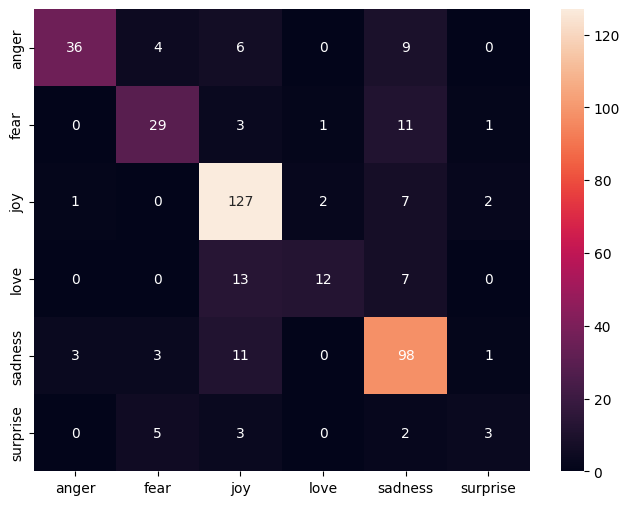

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.show()


In [34]:
def predict_emotion(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)
    return le.inverse_transform(pred)[0]

print(predict_emotion("I am so excited and happy today!"))
print(predict_emotion("I feel scared and anxious"))


joy
fear


Accuracy: 0.7625

Classification Report:

              precision    recall  f1-score   support

       anger       0.90      0.65      0.76        55
        fear       0.71      0.64      0.67        45
         joy       0.78      0.91      0.84       139
        love       0.80      0.38      0.51        32
     sadness       0.73      0.84      0.78       116
    surprise       0.43      0.23      0.30        13

    accuracy                           0.76       400
   macro avg       0.72      0.61      0.64       400
weighted avg       0.76      0.76      0.75       400



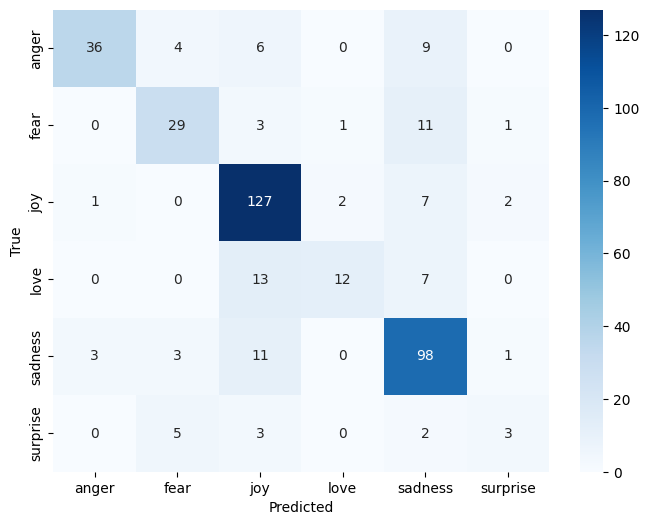

In [35]:
# Cell 8 — evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_test_pred = model.predict(X_test_vec)
# map numeric back to labels if needed
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("True"); plt.show()


In [36]:
# Cell 9 — save model artifacts
import joblib
joblib.dump(model, 'emotion_model_final.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer_final.joblib')
joblib.dump(le, 'label_encoder_final.joblib')
print("Saved files: emotion_model_final.joblib, tfidf_vectorizer_final.joblib, label_encoder_final.joblib")

from google.colab import files
files.download('emotion_model_final.joblib')
files.download('tfidf_vectorizer_final.joblib')
files.download('label_encoder_final.joblib')


Saved files: emotion_model_final.joblib, tfidf_vectorizer_final.joblib, label_encoder_final.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# Cell 10 — quick demo
def predict_emotion(texts):
    txts = [clean_text(t) for t in texts]
    Xv = tfidf.transform(txts)
    preds = model.predict(Xv)
    return le.inverse_transform(preds)

print(predict_emotion(["I am so happy today!", "I feel very sad and lonely"]))


['joy' 'sadness']
